# Barcelona vs Real Madrid：事件可视化实验

**对象**：已经完成 00-01、正在学习 StatsBomb event JSON 的学习者。  
**先修**：知道一行 event 表示一个被记录的比赛事件，并理解嵌套字段只适用于特定事件类型。

本实验回答一个描述性问题：在 match `3773585` 中，两队记录到的传球距离与空间分布、射门时机与 xG、首次换人前的传球连接有什么不同？事件数据又能怎样描述 Messi 的接球和持球行为位置？

完成后，你应该能：

- 为每张图说清分析单位、筛选条件和共同比较基准；
- 正确处理 `pass.outcome` 的结构性缺失；
- 用 `mplsoccer` 复现原书 Chapter 3 的 KDE/hexbin 热图；
- 区分事件位置热区与连续移动轨迹。


## 路线图与口径

1. 加载 events 与 lineups，显式展开四类分析表。
2. 检查类型相关的缺失值，而不是对整张稀疏宽表统一填充。
3. 比较传球距离、射门 xG、累计射门和传球起点热区。
4. 在共同时间窗口内构造 passing networks。
5. 分开绘制 Messi 的接球位置和记录到的持球行为起点。

热图参数参考原书仓库的 [advanced mplsoccer notebook](https://github.com/SoccerAnalyticsML/Soccer-Analytics-with-Machine-Learning/blob/main/extras/chapter-3/05-advanced-visualizations-mplsoccer.ipynb) 与 [Japan case study](https://github.com/SoccerAnalyticsML/Soccer-Analytics-with-Machine-Learning/blob/main/extras/chapter-3/07-case-study-japan-wwc2019.ipynb)：StatsBomb pitch、深色背景、10 层 `YlOrRd` KDE，以及 `gridsize=25` 的 `Blues` hexbin。原书的 `shade=True` 已被 seaborn 弃用，这里用等价的 `fill=True`。


In [1]:
from __future__ import annotations

import json
import math
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mplsoccer import Pitch

from football_analytics import get_open_data_root

MATCH_ID = 3773585
MESSI_ID = 5503
TEAM_ORDER = ["Barcelona", "Real Madrid"]
TEAM_COLORS = {"Barcelona": "#A50044", "Real Madrid": "#FEBE10"}
PITCH_COLOR = "#22312b"
LINE_COLOR = "#efefef"
ON_BALL_TYPES = {"Pass", "Carry", "Dribble", "Shot"}

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})


## 1. 从嵌套 JSON 构造按事件类型分析的表

我们不先制造一张把所有空值填满的总表，而是按问题展开 Pass、Shot、Substitution 和全部带位置事件。这样 `pass.outcome` 为空可以按 schema 解读为成功，而 Shot 行没有 `pass.outcome` 仍然只是“字段不适用”。


In [2]:
open_data_root = get_open_data_root()
events_path = open_data_root / "data" / "events" / f"{MATCH_ID}.json"
lineups_path = open_data_root / "data" / "lineups" / f"{MATCH_ID}.json"
events = json.loads(events_path.read_text(encoding="utf-8"))
lineups = json.loads(lineups_path.read_text(encoding="utf-8"))

def event_clock(event: dict) -> float:
    return float(event["minute"]) + float(event["second"]) / 60

pass_rows = []
shot_rows = []
located_event_rows = []
substitution_rows = []

for event in events:
    event_type = event["type"]["name"]
    team = event.get("team", {}).get("name")
    player = event.get("player", {})
    location = event.get("location")
    base = {
        "event_id": event["id"],
        "index": event["index"],
        "period": event["period"],
        "minute": event["minute"],
        "second": event["second"],
        "clock": event_clock(event),
        "team": team,
        "player_id": player.get("id"),
        "player": player.get("name"),
        "type": event_type,
    }
    if location is not None:
        located_event_rows.append({**base, "x": location[0], "y": location[1]})
    if event_type == "Pass":
        detail = event["pass"]
        end = detail.get("end_location")
        recipient = detail.get("recipient", {})
        outcome = detail.get("outcome", {}).get("name")
        pass_rows.append({
            **base,
            "x": location[0] if location else np.nan,
            "y": location[1] if location else np.nan,
            "end_x": end[0] if end else np.nan,
            "end_y": end[1] if end else np.nan,
            "length": detail.get("length"),
            "recipient_id": recipient.get("id"),
            "recipient": recipient.get("name"),
            "outcome": outcome,
            "success": outcome is None,
            "play_pattern": event["play_pattern"]["name"],
        })
    elif event_type == "Shot":
        detail = event["shot"]
        shot_rows.append({
            **base,
            "xg": detail.get("statsbomb_xg"),
            "outcome": detail.get("outcome", {}).get("name"),
            "shot_type": detail.get("type", {}).get("name"),
            "is_goal": detail.get("outcome", {}).get("name") == "Goal",
        })
    elif event_type == "Substitution":
        substitution_rows.append(base)

passes = pd.DataFrame(pass_rows)
shots = pd.DataFrame(shot_rows)
located_events = pd.DataFrame(located_event_rows)
substitutions = pd.DataFrame(substitution_rows)
jerseys = {
    int(player["player_id"]): int(player["jersey_number"])
    for team in lineups
    for player in team["lineup"]
}

assert len(events) == 4213
assert passes["event_id"].is_unique and shots["event_id"].is_unique
assert set(passes["team"].unique()) == set(TEAM_ORDER)
assert len(shots) == 26 and shots["xg"].notna().all()
assert not substitutions.empty

pd.DataFrame({
    "events": [len(events)],
    "passes": [len(passes)],
    "shots": [len(shots)],
    "located_events": [len(located_events)],
    "substitutions": [len(substitutions)],
})


,events,passes,shots,located_events,substitutions
0,4213,1203,26,4186,7


### 类型相关的 missing-data 检查

下面只检查每种分析实际需要的字段。对 Pass 而言，空 `outcome` 是成功标记，不是待填补的数据；但成功传球缺少 recipient、Pass 缺少起终点，或 Shot 缺少 xG，才会阻止对应分析。


In [3]:
quality = pd.Series({
    "Pass missing start location": int(passes[["x", "y"]].isna().any(axis=1).sum()),
    "Pass missing end location": int(passes[["end_x", "end_y"]].isna().any(axis=1).sum()),
    "Successful Pass missing recipient": int(
        passes.loc[passes["success"], "recipient_id"].isna().sum()
    ),
    "Shot missing xG": int(shots["xg"].isna().sum()),
    "Located event outside StatsBomb pitch": int(
        (~located_events["x"].between(0, 120) | ~located_events["y"].between(0, 80)).sum()
    ),
}, name="missing_or_invalid_rows").to_frame()

assert (quality["missing_or_invalid_rows"] == 0).all()
type_counts = pd.Series(Counter(event["type"]["name"] for event in events))
display(quality)
display(type_counts.sort_values(ascending=False).head(10).rename("event_count").to_frame())


,missing_or_invalid_rows
Pass missing start location,0
Pass missing end location,0
Successful Pass missing recipient,0
Shot missing xG,0
Located event outside StatsBomb pitch,0


,event_count
Pass,1203
Ball Receipt*,1169
Carry,984
Pressure,340
Ball Recovery,95
Duel,58
Block,55
Dribble,44
Goal Keeper,33
Dribbled Past,31


## 2. 双方成功 Regular Play 传球距离分布（1 米一箱）

**问题与样本**：两队在常规比赛阶段完成的传球，记录距离怎样分布？每行是一条成功且 `play_pattern == Regular Play` 的 Pass。  
**算法与读法**：两队使用同一组 1 米箱；纵轴是各队自身样本百分比，所以形状可以比较，不会仅因传球总数更多而整体更高。虚线是均值。  
**边界**：这不衡量传球难度、推进价值或球队赛季风格。更可信的下一步是同时检查所有 play pattern、比赛状态和多场样本的敏感性。


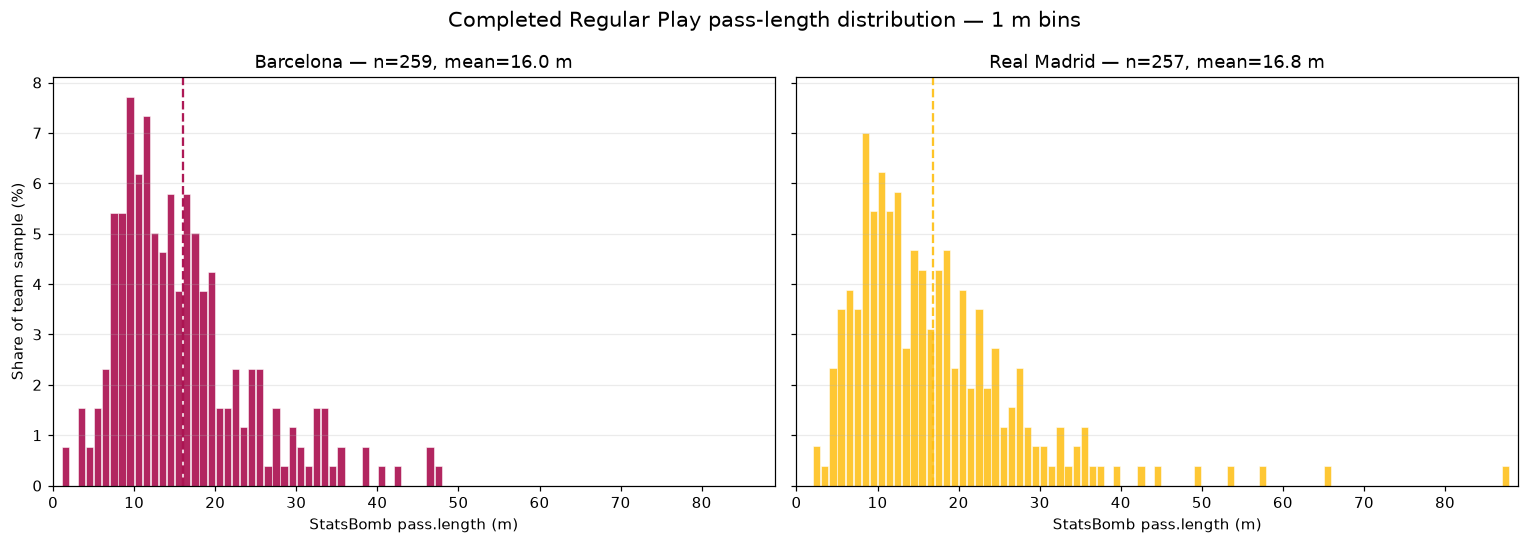

In [4]:
distance_sample = passes.loc[
    passes["success"] & passes["play_pattern"].eq("Regular Play")
].copy()
distance_bins = np.arange(0, math.ceil(distance_sample["length"].max()) + 2, 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for ax, team in zip(axes, TEAM_ORDER, strict=True):
    values = distance_sample.loc[distance_sample["team"].eq(team), "length"]
    weights = np.full(len(values), 100 / len(values))
    ax.hist(
        values, bins=distance_bins, weights=weights, histtype="bar", rwidth=0.9,
        color=TEAM_COLORS[team], alpha=0.85, edgecolor="white", linewidth=0.4,
    )
    ax.axvline(values.mean(), color=TEAM_COLORS[team], linestyle="--", alpha=0.9)
    ax.set_title(f"{team} — n={len(values)}, mean={values.mean():.1f} m")
    ax.set(xlabel="StatsBomb pass.length (m)", xlim=(distance_bins.min(), distance_bins.max()))
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Share of team sample (%)")
fig.suptitle("Completed Regular Play pass-length distribution — 1 m bins", fontsize=14)
fig.tight_layout()
plt.show()


## 3. 双方全部射门的 xG 分布（0.1 一箱）

**问题与样本**：本场全部 26 次 Shot 的单次机会质量分布怎样？  
**算法与读法**：每队单独画计数柱状图，共用 0.1 xG 箱和 y 轴；标题报告射门数与总 xG，菱形/虚线标出 Penalty。  
**边界**：26 次射门的直方图非常稀疏，不能据此估计稳定分布，也不能把 xG 等同于进球概率的赛后确定性。更可信的下一步是展示每次射门位置、模型版本和多场样本。


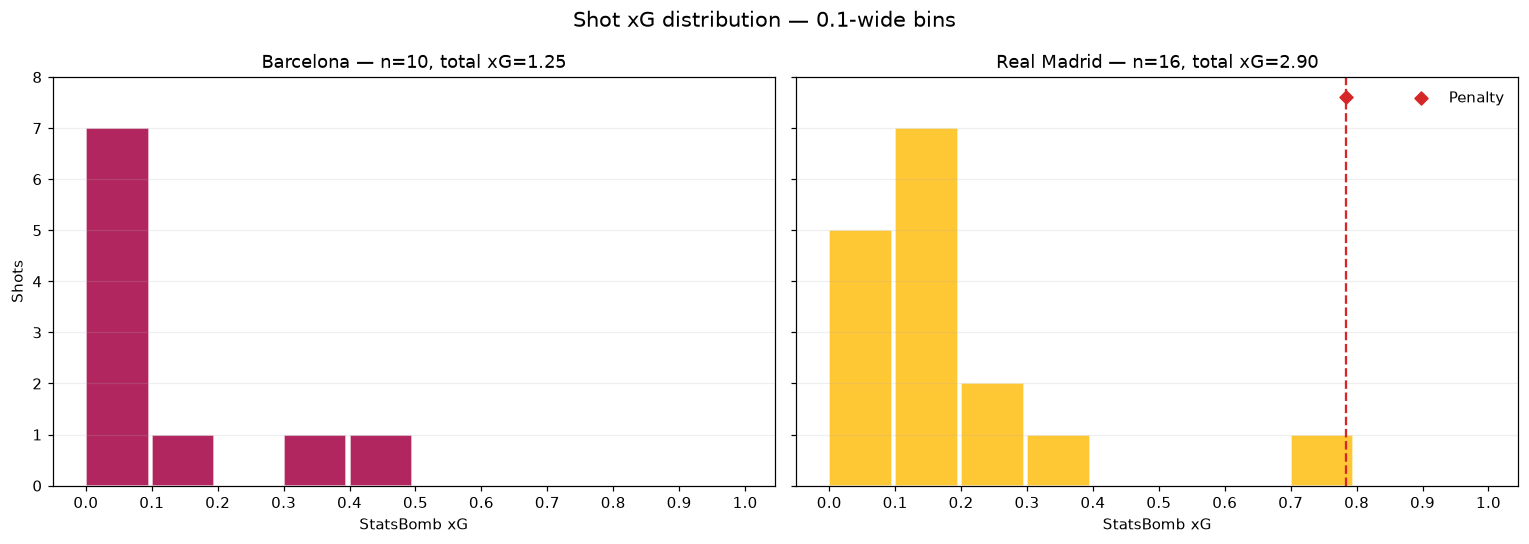

In [5]:
xg_bins = np.arange(0, 1.01, 0.1)
team_histograms = {
    team: np.histogram(shots.loc[shots["team"].eq(team), "xg"], bins=xg_bins)[0]
    for team in TEAM_ORDER
}
shared_ymax = max(values.max() for values in team_histograms.values()) + 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for ax, team in zip(axes, TEAM_ORDER, strict=True):
    team_shots = shots.loc[shots["team"].eq(team)].sort_values("xg")
    counts = team_histograms[team]
    ax.bar(xg_bins[:-1], counts, width=0.095, align="edge", color=TEAM_COLORS[team], alpha=0.85, edgecolor="white")
    penalties = team_shots.loc[team_shots["shot_type"].eq("Penalty"), "xg"]
    for penalty_xg in penalties:
        ax.axvline(penalty_xg, color="#d62728", linestyle="--", linewidth=1.5)
        ax.scatter(penalty_xg, shared_ymax - 0.4, marker="D", color="#d62728", zorder=3, label="Penalty")
    ax.set_title(f"{team} — n={len(team_shots)}, total xG={team_shots['xg'].sum():.2f}")
    ax.set(xlabel="StatsBomb xG", ylim=(0, shared_ymax), xticks=xg_bins)
    ax.grid(axis="y", alpha=0.2)
    if not penalties.empty:
        ax.legend(frameon=False, loc="upper right")
axes[0].set_ylabel("Shots")
fig.suptitle("Shot xG distribution — 0.1-wide bins", fontsize=14)
fig.tight_layout()
plt.show()


## 4. 90 分钟内累计射门

**问题与样本**：两队的射门次数在比赛时间中何时累积？仍使用全部 Shot。  
**算法与读法**：事件时间为 `minute + second / 60`，阶梯只在射门发生时上升；45 分钟线帮助阅读上下半场，星号标记 Goal。  
**边界**：射门累计不包含机会质量、控球阶段或比分影响，水平段也不等于没有进攻。更可信的下一步是叠加累计 xG、比分状态和视频时间线。


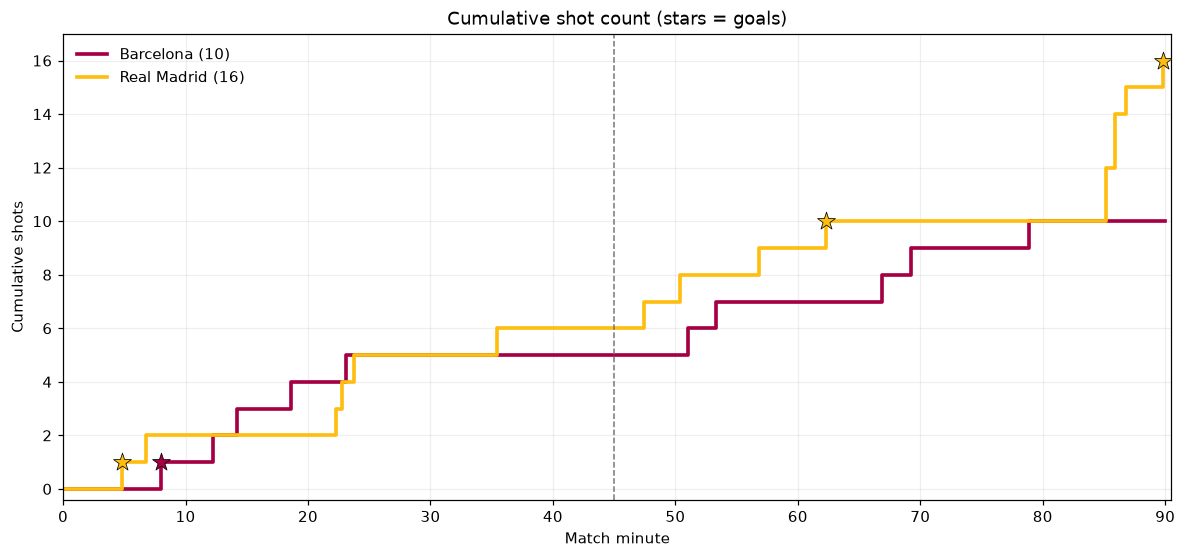

In [6]:
fig, ax = plt.subplots(figsize=(13, 5.5))
for team in TEAM_ORDER:
    team_shots = shots.loc[shots["team"].eq(team)].sort_values(["index"])
    times = team_shots["clock"].clip(upper=90).to_numpy()
    x = np.r_[0, times, 90]
    y = np.r_[0, np.arange(1, len(times) + 1), len(times)]
    ax.step(x, y, where="post", linewidth=2.4, color=TEAM_COLORS[team], label=f"{team} ({len(times)})")
    goal_positions = np.flatnonzero(team_shots["is_goal"].to_numpy())
    ax.scatter(times[goal_positions], goal_positions + 1, marker="*", s=150, color=TEAM_COLORS[team], edgecolor="black", linewidth=0.5, zorder=3)

ax.axvline(45, color="#777777", linestyle="--", linewidth=1)
team_shot_max = int(shots.groupby("team").size().max())
ax.set(xlim=(0, 90.5), ylim=(-0.4, team_shot_max + 1), xlabel="Match minute", ylabel="Cumulative shots", title="Cumulative shot count (stars = goals)")
ax.set_xticks(np.arange(0, 91, 10))
ax.set_yticks(np.arange(0, team_shot_max + 1, 2))
ax.grid(alpha=0.2)
ax.legend(frameon=False)
plt.show()


## 5. 双方传球起点热区：原书 KDE + 可比 hexbin

**问题与样本**：所有具有起点坐标的 Pass 在哪里被记录？这里故意包含成功和失败、Regular Play 与 restart，因为问题是“传球事件从哪里开始”。  
**算法与读法**：第一张沿用原书的每队 KDE，颜色表示该队自身平滑密度；第二张用 `gridsize=25` hexbin 与共享 count 色阶，才适合比较绝对事件数。StatsBomb 坐标中每队进攻方向统一为从左向右。  
**边界**：KDE 受带宽影响，起点密集不等于控制空间，也没有表达传球终点和成功率。更可信的下一步是改变网格/带宽，并按 play pattern、比赛状态和传球结果拆分。


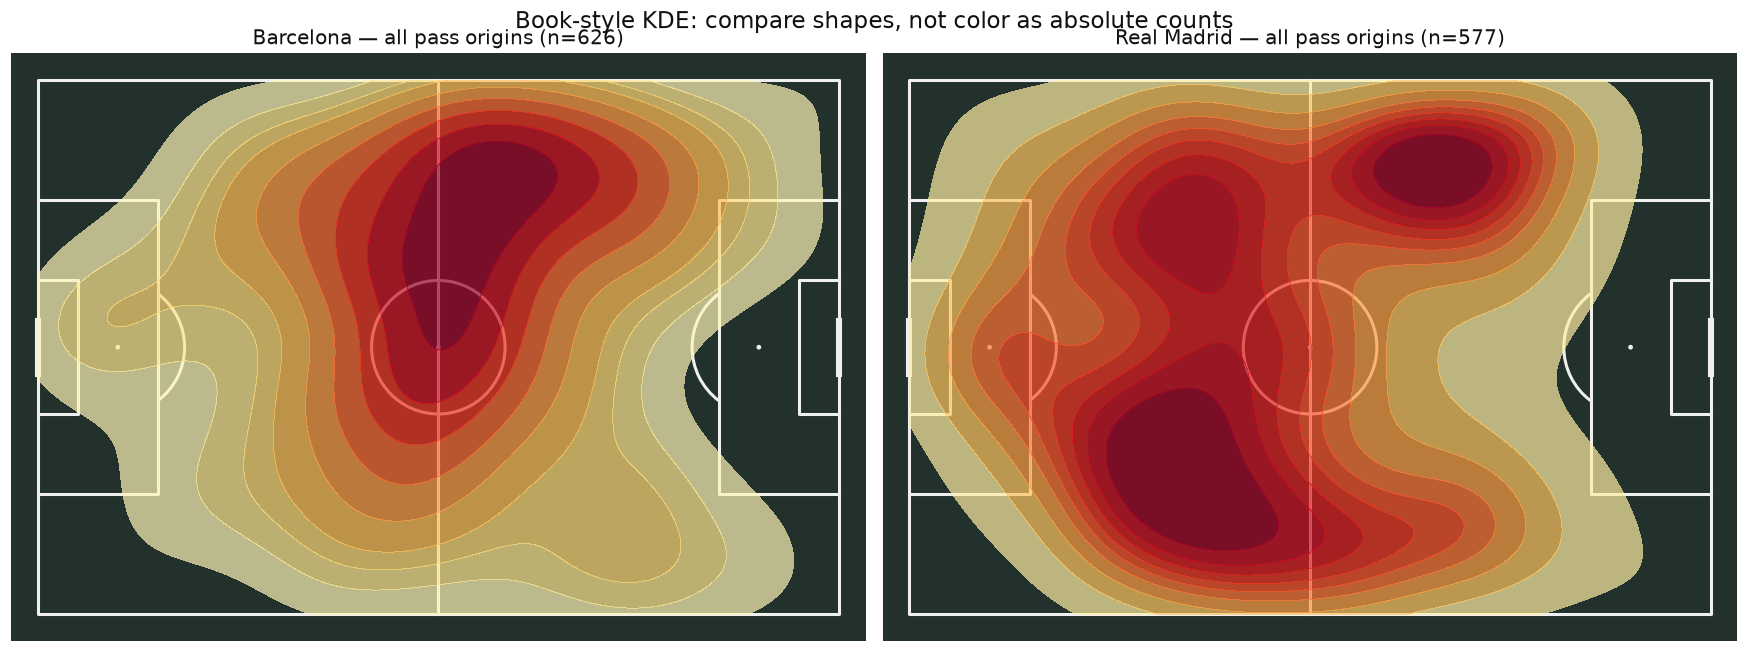

In [7]:
pitch = Pitch(pitch_type="statsbomb", pitch_color=PITCH_COLOR, line_color=LINE_COLOR, linewidth=2)
fig, axes = pitch.draw(nrows=1, ncols=2, figsize=(16, 6))
for ax, team in zip(axes, TEAM_ORDER, strict=True):
    team_passes = passes.loc[passes["team"].eq(team)].dropna(subset=["x", "y"])
    pitch.kdeplot(
        team_passes["x"], team_passes["y"], ax=ax, fill=True, levels=10,
        alpha=0.7, cmap="YlOrRd", zorder=1,
    )
    ax.set_title(f"{team} — all pass origins (n={len(team_passes)})", color="#111111", fontsize=13)
fig.suptitle("Book-style KDE: compare shapes, not color as absolute counts", color="#111111", fontsize=15)
plt.show()


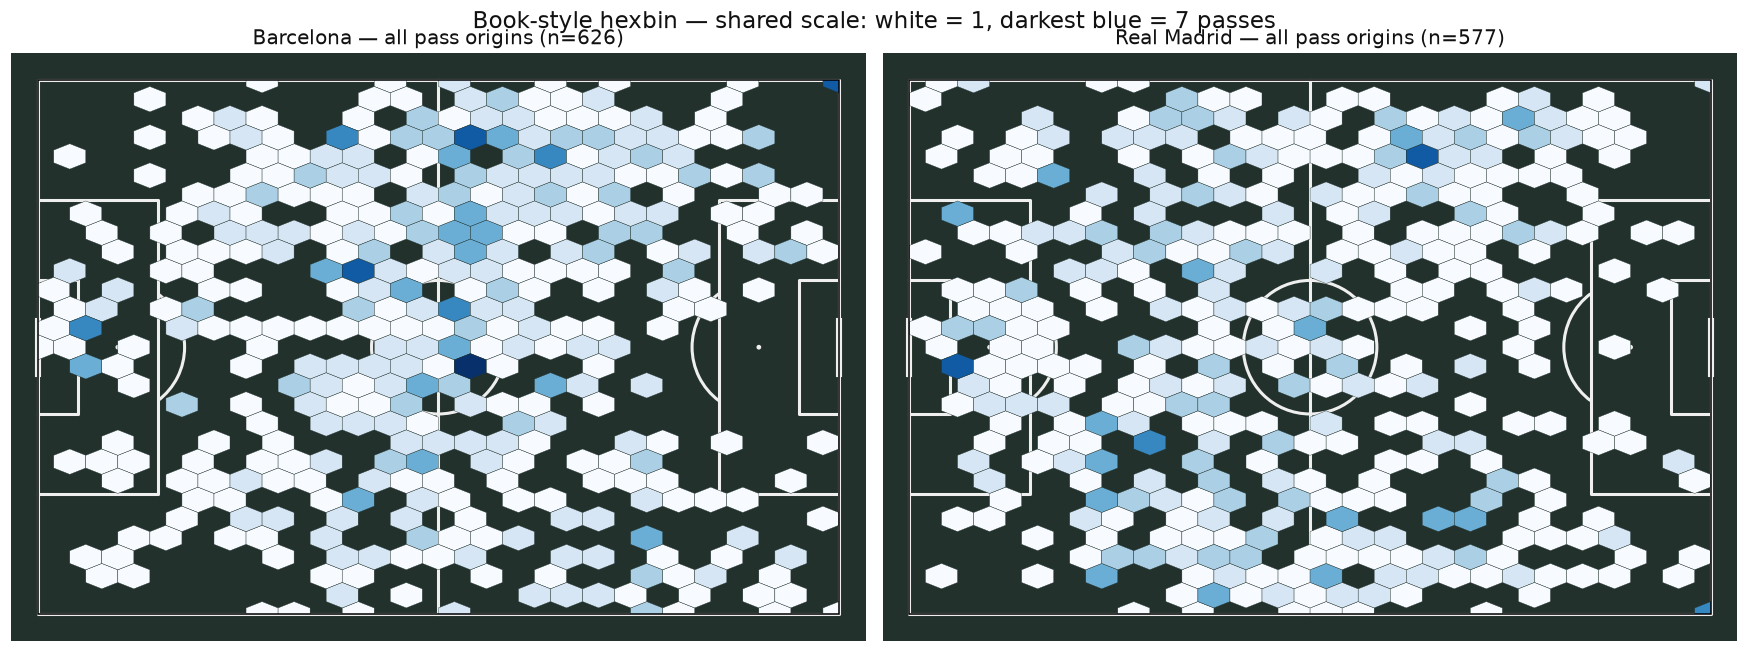

In [8]:
fig, axes = pitch.draw(nrows=1, ncols=2, figsize=(16, 6))
hexmaps = []
for ax, team in zip(axes, TEAM_ORDER, strict=True):
    team_passes = passes.loc[passes["team"].eq(team)].dropna(subset=["x", "y"])
    hexmap = pitch.hexbin(
        team_passes["x"], team_passes["y"], ax=ax, gridsize=25,
        cmap="Blues", mincnt=1, edgecolors=PITCH_COLOR, linewidths=0.25,
    )
    hexmaps.append(hexmap)
    ax.set_title(f"{team} — all pass origins (n={len(team_passes)})", color="#111111", fontsize=13)
shared_max = max(float(np.nanmax(hexmap.get_array())) for hexmap in hexmaps)
for hexmap in hexmaps:
    hexmap.set_clim(1, shared_max)
fig.suptitle(
    f"Book-style hexbin — shared scale: white = 1, darkest blue = {int(shared_max)} passes",
    color="#111111", fontsize=15,
)
plt.show()


## 6. Passing networks：共同截到第一次换人前

**问题与样本**：在双方阵容尚未发生变化的共同窗口内，成功传球形成了哪些记录到的连接？每条边聚合一对球员之间双向的成功传球。  
**算法与读法**：节点位置是球员传球起点与接球终点的平均；节点大小是传出+接到次数；边宽是球员对传球数。两队共用节点和边尺度，只显示至少 3 次的边以保持可读。节点标签为球衣号码。  
**边界**：平均位置不是阵型站位，边也不表达被压迫程度、可选路线或传球价值。第一次换人本身可能由伤病或战术引起。更可信的下一步是测试边阈值，区分方向，并用视频或 tracking 验证站位解释。


In [9]:
first_substitution = substitutions.sort_values("index").iloc[0]
network_passes = passes.loc[
    passes["success"]
    & passes["recipient_id"].notna()
    & passes["index"].lt(first_substitution["index"])
].copy()
network_passes[["player_id", "recipient_id"]] = network_passes[["player_id", "recipient_id"]].astype(int)

position_rows = []
for row in network_passes.itertuples(index=False):
    position_rows.extend([
        {"team": row.team, "player_id": row.player_id, "x": row.x, "y": row.y},
        {"team": row.team, "player_id": row.recipient_id, "x": row.end_x, "y": row.end_y},
    ])
positions_raw = pd.DataFrame(position_rows)
positions = (
    positions_raw.groupby(["team", "player_id"], as_index=False)
    .agg(x=("x", "mean"), y=("y", "mean"), involvement=("x", "size"))
)

network_passes["player_a"] = network_passes[["player_id", "recipient_id"]].min(axis=1)
network_passes["player_b"] = network_passes[["player_id", "recipient_id"]].max(axis=1)
edges = (
    network_passes.groupby(["team", "player_a", "player_b"], as_index=False)
    .size().rename(columns={"size": "pass_count"})
)
EDGE_MIN = 3
edges = edges.loc[edges["pass_count"].ge(EDGE_MIN)].copy()
max_edge = edges["pass_count"].max()
max_involvement = positions["involvement"].max()

print(
    f"Common window ends before the first substitution: {first_substitution['team']} at "
    f"{int(first_substitution['minute'])}:{int(first_substitution['second']):02d}; "
    f"successful passes in network sample = {len(network_passes)}."
)
display(network_passes.groupby("team").size().rename("successful_passes").to_frame())


Common window ends before the first substitution: Real Madrid at 42:06; successful passes in network sample = 504.


,successful_passes
team,
Barcelona,215
Real Madrid,289


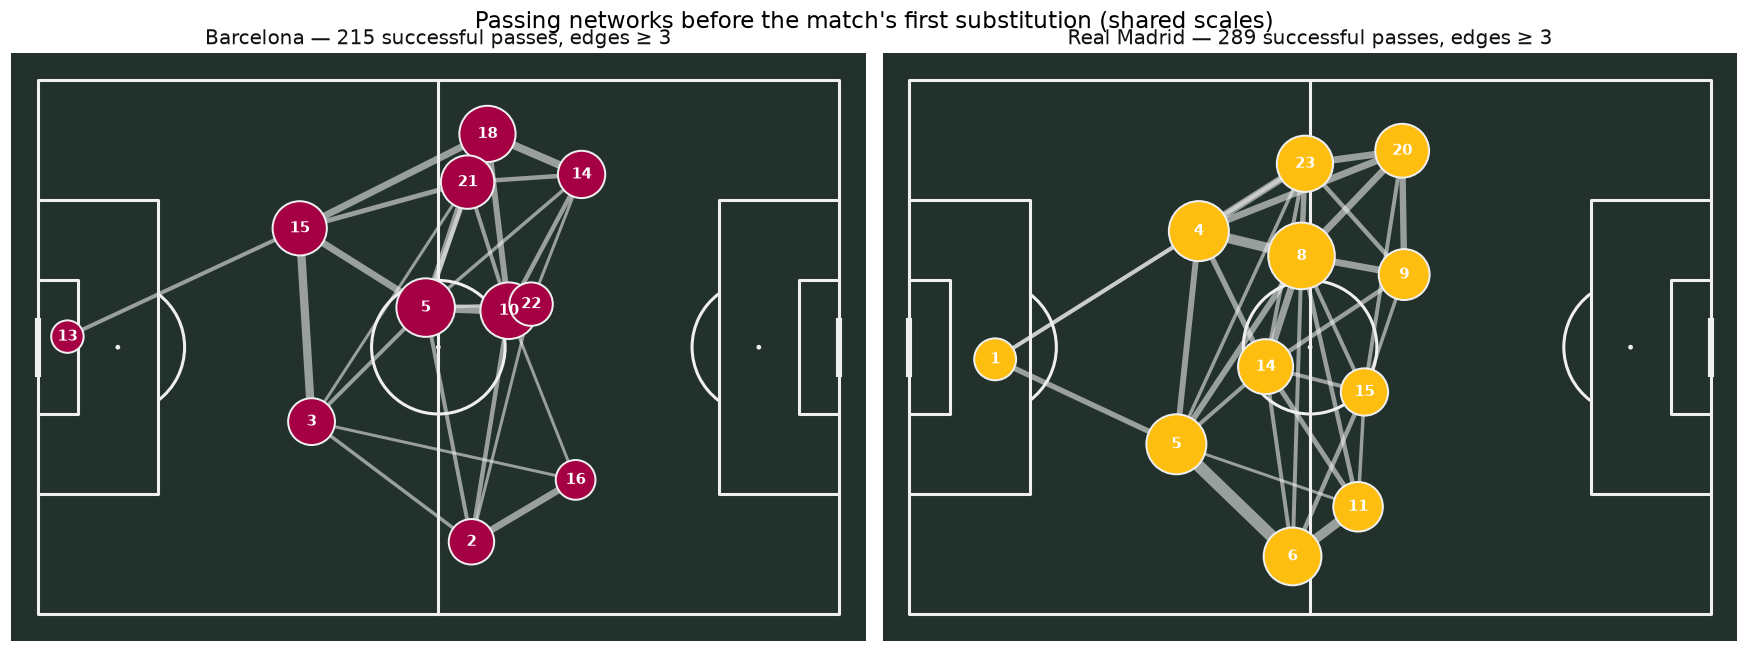

In [10]:
fig, axes = pitch.draw(nrows=1, ncols=2, figsize=(16, 6))
for ax, team in zip(axes, TEAM_ORDER, strict=True):
    team_positions = positions.loc[positions["team"].eq(team)].set_index("player_id")
    team_edges = edges.loc[edges["team"].eq(team)]
    for edge in team_edges.itertuples(index=False):
        start = team_positions.loc[int(edge.player_a)]
        end = team_positions.loc[int(edge.player_b)]
        pitch.lines(
            start.x, start.y, end.x, end.y, ax=ax,
            lw=1 + 7 * edge.pass_count / max_edge, color=LINE_COLOR, alpha=0.58, zorder=2,
        )
    sizes = 300 + 1600 * team_positions["involvement"] / max_involvement
    pitch.scatter(
        team_positions["x"], team_positions["y"], s=sizes, ax=ax,
        color=TEAM_COLORS[team], edgecolors=LINE_COLOR, linewidth=1.3, zorder=3,
    )
    for player_id, node in team_positions.iterrows():
        ax.text(node.x, node.y, str(jerseys[int(player_id)]), ha="center", va="center", color="white", weight="bold", zorder=4)
    team_n = int(network_passes["team"].eq(team).sum())
    ax.set_title(f"{team} — {team_n} successful passes, edges ≥ {EDGE_MIN}", color="#111111", fontsize=13)
fig.suptitle("Passing networks before the match's first substitution (shared scales)", fontsize=15)
plt.show()


## 7. Messi：接球位置与记录到的持球行为起点

**问题与样本**：Messi 在哪里被记录为 Ball Receipt，以及在哪里开始 Pass、Carry、Dribble 或 Shot？两张图各以一个被记录的事件为单位。  
**算法与读法**：两组位置分别做与原书相同参数的 KDE；颜色只表达各自样本内的平滑密度，标题报告事件数。  
**边界**：这不是 Messi 的“移动热区”。事件数据没有连续轨迹，Ball Receipt 也不是每次真实触球；本场 360 freeze frame 没有可用于身份关联的 player ID。更可信的检查需要带身份的 tracking/360 数据、视频和 off-ball 定义。


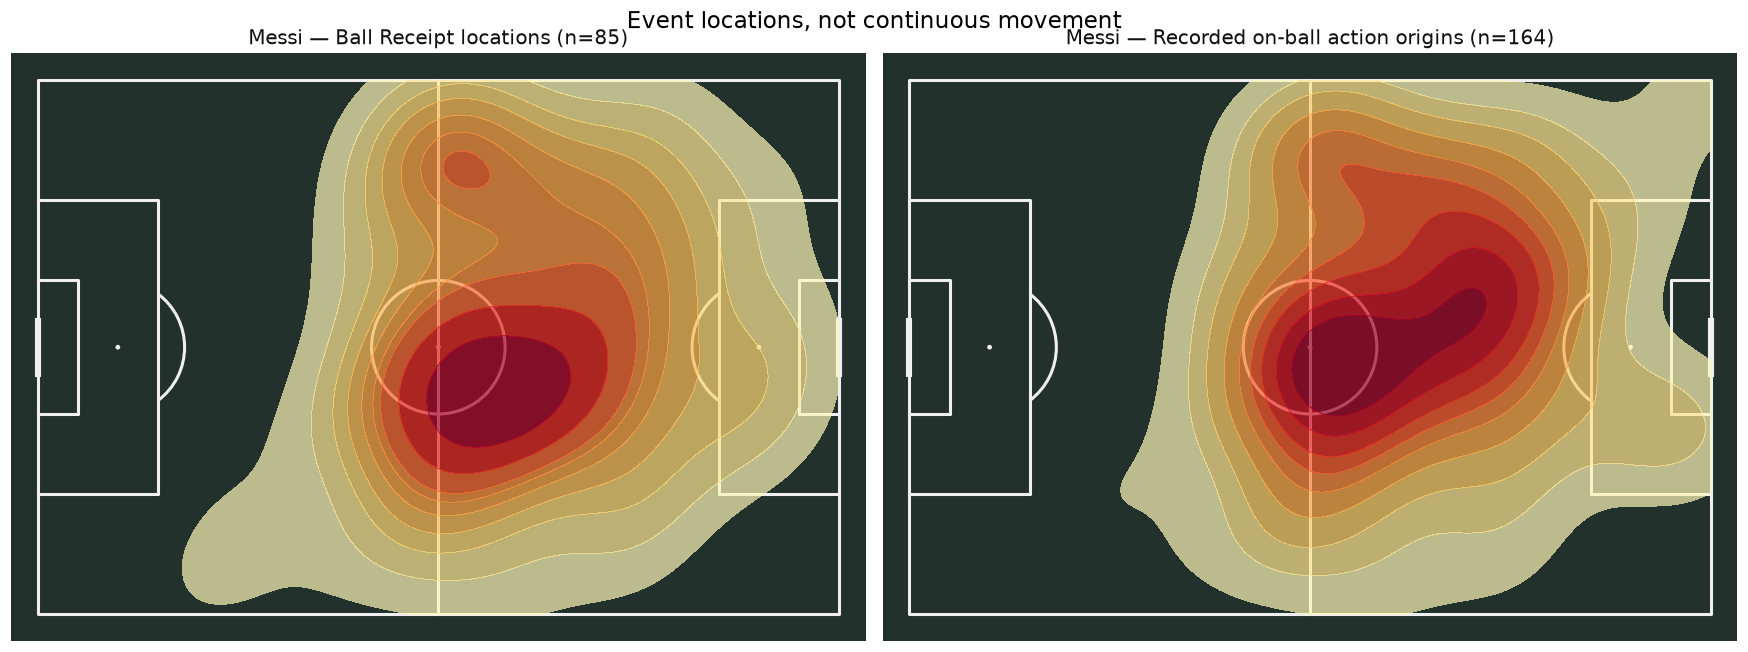

,event_count
type,
Carry,78
Pass,73
Dribble,10
Shot,3


In [11]:
messi_events = located_events.loc[located_events["player_id"].eq(MESSI_ID)].copy()
messi_receipts = messi_events.loc[messi_events["type"].eq("Ball Receipt*")]
messi_on_ball = messi_events.loc[messi_events["type"].isin(ON_BALL_TYPES)]
assert len(messi_receipts) == 85
assert set(messi_on_ball["type"].unique()) == ON_BALL_TYPES

fig, axes = pitch.draw(nrows=1, ncols=2, figsize=(16, 6))
panels = [
    (axes[0], messi_receipts, "Ball Receipt locations"),
    (axes[1], messi_on_ball, "Recorded on-ball action origins"),
]
for ax, sample, title in panels:
    pitch.kdeplot(
        sample["x"], sample["y"], ax=ax, fill=True, levels=10,
        alpha=0.7, cmap="YlOrRd", zorder=1,
    )
    ax.set_title(f"Messi — {title} (n={len(sample)})", color="#111111", fontsize=13)
fig.suptitle("Event locations, not continuous movement", fontsize=15)
plt.show()
display(messi_on_ball.groupby("type").size().sort_values(ascending=False).rename("event_count").to_frame())


## 结论应停在哪一层？

- **数据事实**：样本中有多少 Pass、Shot、Ball Receipt，哪些必要字段缺失。
- **指标结果**：某队的距离分布、累计射门、hexbin 计数或 network 边更集中在哪里。
- **足球解释**：这些模式可能与推进选择、比赛状态或角色有关，但单场 event data 不能确认原因。
- **未验证假设**：阵型、压迫、无球跑动或教练意图造成了图中的差异。

先独立阅读每张图并写下两条数据事实、一条指标结果和一个未验证假设。不要把颜色更深直接写成“控制力更强”。


## 练习（先预测，再改代码）

1. 将传球距离样本从成功 Regular Play 改为全部 Pass。预测哪一队均值变化更大，并解释 restart 为什么会改变问题。
2. 把 network 的 `EDGE_MIN` 从 3 改成 5。记录消失的连接，并区分“图上消失”与“没有发生”。
3. 将 KDE 改为只看成功传球，或调整 `levels`。指出视觉变化来自数据筛选还是绘图参数。
4. 在累计射门旁增加累计 xG 阶梯图。比较“射门数领先”和“机会质量领先”是否在同一时刻出现。
